In [14]:
import mujoco
import mujoco.viewer
import time
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation
import sys

# Helper function to bring window to foreground on Windows
def bring_window_to_foreground():
    """Bring the MuJoCo viewer window to the foreground (Windows only)"""
    if sys.platform == 'win32':
        import ctypes
        import subprocess
        
        try:
            # Method 1: Try using subprocess to activate the last created window
            # This is more reliable than direct ctypes calls
            subprocess.Popen("powershell -Command \"[Windows.System.Launcher]::LaunchUriAsync('ms-settings:') | Out-Null; Start-Sleep -Milliseconds 100\"", shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            time.sleep(0.1)
            
            # Method 2: Try to find and activate any GLFW window (MuJoCo uses GLFW)
            hwnd = ctypes.windll.user32.FindWindowW(ctypes.c_wchar_p("GLFW30"), None)
            if hwnd:
                ctypes.windll.user32.SetForegroundWindow(hwnd)
                time.sleep(0.1)
                return
            
            # Method 3: Use keyboard shortcut to switch windows (Alt+Tab alternative)
            ctypes.windll.user32.keybd_event(0xA4, 0, 0, 0)  # Alt down
            time.sleep(0.05)
            ctypes.windll.user32.keybd_event(0x09, 0, 0, 0)  # Tab down
            time.sleep(0.05)
            ctypes.windll.user32.keybd_event(0x09, 0, 0x2, 0)  # Tab up
            time.sleep(0.05)
            ctypes.windll.user32.keybd_event(0xA4, 0, 0x2, 0)  # Alt up
            time.sleep(0.1)
            
        except Exception as e:
            print(f"Could not bring window to foreground: {e}")

# Load the Segway model
script_dir = os.getcwd()
if not os.path.exists(os.path.join(script_dir, "segway_2.xml")):
    script_dir = os.path.join(script_dir, "Ozzy")

model = mujoco.MjModel.from_xml_path(os.path.join(script_dir, "segway_2.xml"))
data = mujoco.MjData(model)

# Understanding qpos and qvel:
# The segway body has a <freejoint> which creates 6 DOFs (floating base):
#   qpos[0:3] = [x, y, z] position
#   qpos[3:7] = [qw, qx, qy, qz] quaternion (orientation)
# Additional joints in the model:
#   qpos[7] = ground wheel angle
#   qpos[8] = reaction wheel angle
#
# Similarly for velocity:
#   qvel[0:3] = linear velocities [vx, vy, vz]
#   qvel[3:6] = angular velocities [wx, wy, wz]
#   qvel[6] = ground wheel angular velocity
#   qvel[7] = reaction wheel angular velocity

# Set initial conditions
data.qpos[0] = 0.0      # x position
data.qpos[1] = 0.0      # y position  
data.qpos[2] = 0.0      # z position
# Keep default quaternion (identity) for now

data.qvel[:] = 0.0      # All velocities start at zero

# Tilt the Segway forward by rotating around y-axis by 0.1 rad
rot = Rotation.from_euler('y', 0.1)  # Rotate 0.1 rad around y-axis
quat = rot.as_quat()  # Returns [qx, qy, qz, qw]
data.qpos[3:7] = [quat[3], quat[0], quat[1], quat[2]]  # Convert to MuJoCo format [qw, qx, qy, qz]

mujoco.mj_forward(model, data)

# PID Controller Parameters (tuned for reaction wheel control)
Kp = 100.0   # Proportional gain
Kd = 3.0    # Derivative gain
Ki = 0.5    # Integral gain

dt = model.opt.timestep

print(f"Model loaded successfully!")
print(f"Simulation timestep: {dt} seconds")
print(f"Model structure:")
print(f"  - Free joint (body orientation): qpos[3:7] (quaternion)")
print(f"  - Ground wheel joint: qpos[7]")
print(f"  - Reaction wheel joint: qpos[8]")
print(f"\nControl actuators:")
print(f"  - ctrl[0]: Ground wheel motor (ctrlrange: -1 to 1)")
print(f"  - ctrl[1]: Reaction wheel motor (ctrlrange: -5 to 5)")
print(f"\nPID Controller (for reaction wheel) - Kp: {Kp}, Ki: {Ki}, Kd: {Kd}")

Model loaded successfully!
Simulation timestep: 0.002 seconds
Model structure:
  - Free joint (body orientation): qpos[3:7] (quaternion)
  - Ground wheel joint: qpos[7]
  - Reaction wheel joint: qpos[8]

Control actuators:
  - ctrl[0]: Ground wheel motor (ctrlrange: -1 to 1)
  - ctrl[1]: Reaction wheel motor (ctrlrange: -5 to 5)

PID Controller (for reaction wheel) - Kp: 100.0, Ki: 0.5, Kd: 3.0


In [15]:
# Run simulation for 8 seconds with visualization, collecting data
simulation_time = 8.0
time_elapsed = 0.0
integral_error = 0.0

# Storage arrays for plotting
times = []
x_positions = []
angles = []
x_velocities = []
angle_velocities = []
control_inputs = []

# Reset to initial conditions
data.qpos[0] = 0.0
data.qpos[1] = 0.0
data.qpos[2] = 0.0
rot = Rotation.from_euler('y', 0.1)
quat = rot.as_quat()
data.qpos[3:7] = [quat[3], quat[0], quat[1], quat[2]]

data.qvel[:] = 0.0
mujoco.mj_forward(model, data)

print(f"Running simulation for {simulation_time} seconds...")
print(f"Note: Using reaction wheel motor (joint_reaction_wheel) for control")
print(f"MuJoCo viewer will pop up as active window")

# Launch the MuJoCo viewer
with mujoco.viewer.launch_passive(model, data) as viewer:
    # Bring the viewer window to the foreground immediately
    bring_window_to_foreground()
    
    while time_elapsed < simulation_time and viewer.is_running():
        # Extract angle from vertical from the quaternion
        quat = data.qpos[3:7]  # [qw, qx, qy, qz]
        rot = Rotation.from_quat([quat[1], quat[2], quat[3], quat[0]])
        euler_angles = rot.as_euler('xyz')
        theta = euler_angles[1]  # Pitch angle
        
        # Angular velocity (pitch rate)
        theta_dot = data.qvel[4]  # wy is pitch rate
        
        # Horizontal velocity
        x_dot = data.qvel[0]
        
        # Error
        angle_error = theta
        
        # Accumulate integral error
        integral_error += angle_error * dt
        
        # PID control law
        u = Kp * angle_error + Ki * integral_error + Kd * theta_dot
        
        # Saturate force within motor limits (ctrlrange="-5 5" for reaction wheel)
        u = max(min(u, 5.0), -5.0)
        
        # Apply control to REACTION WHEEL motor (ctrl[1])
        data.ctrl[0] = -u
        
        # Collect data
        times.append(time_elapsed)
        x_positions.append(data.qpos[0])
        angles.append(theta)
        x_velocities.append(x_dot)
        angle_velocities.append(theta_dot)
        control_inputs.append(u)
        
        # Step simulation
        mujoco.mj_step(model, data)
        viewer.sync()  # Sync viewer with simulation state
        
        time_elapsed += dt

print(f"Simulation complete! Collected {len(times)} data points.")
print(f"Final angle: {angles[-1]:.3f} rad")
print(f"Final position: {x_positions[-1]:.3f} m")

Running simulation for 8.0 seconds...
Note: Using reaction wheel motor (joint_reaction_wheel) for control
MuJoCo viewer will pop up as active window
Simulation complete! Collected 4001 data points.
Final angle: -0.000 rad
Final position: 0.011 m


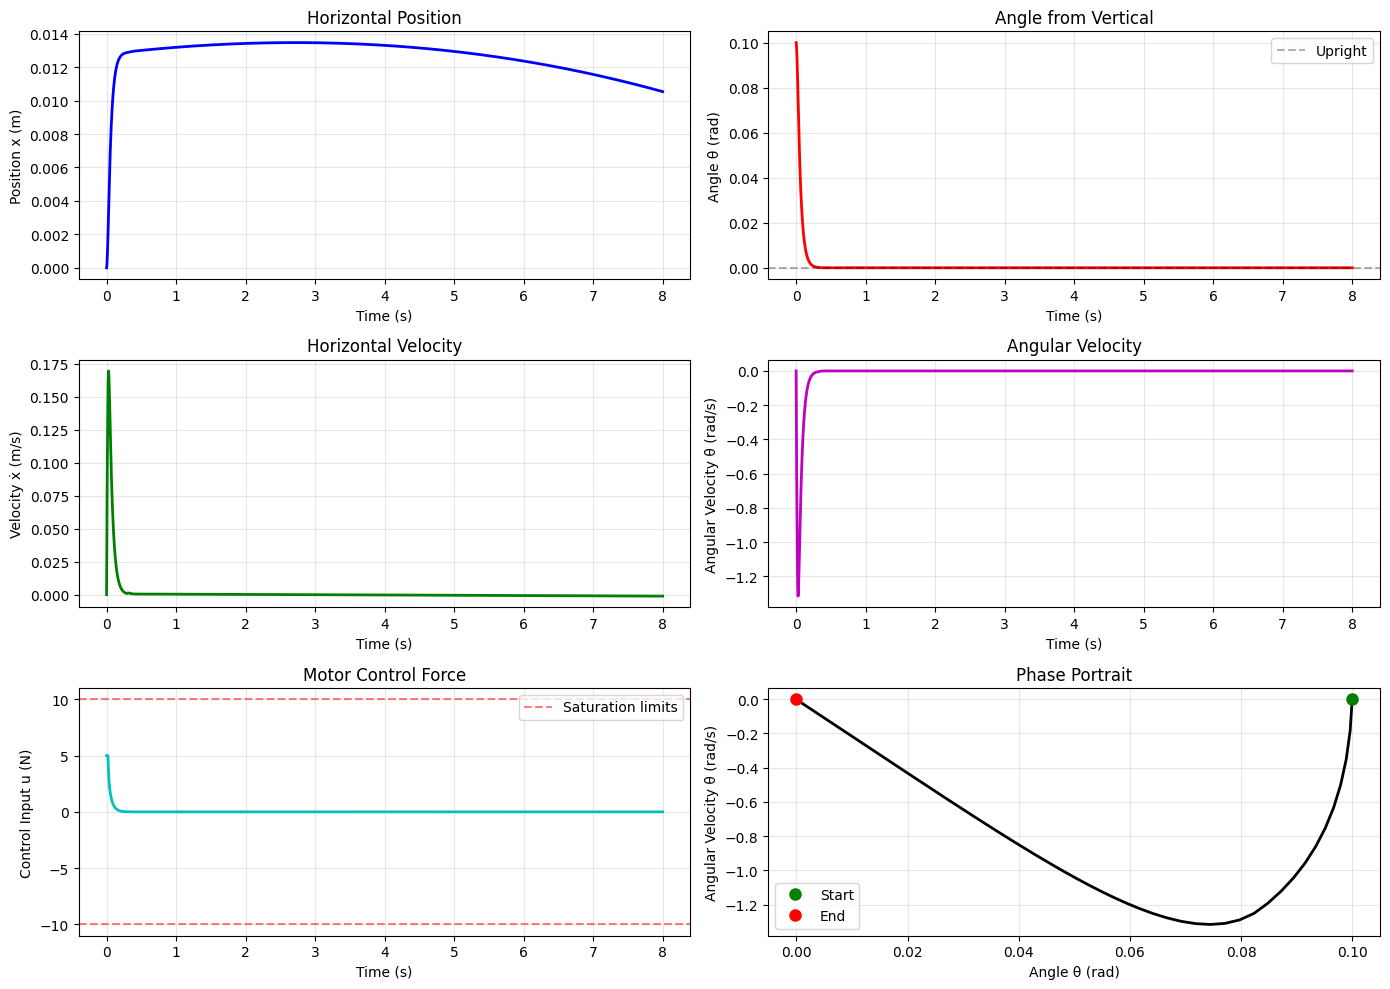


Simulation Summary:
  Max angle deviation: 0.100 rad
  Final angle: -0.000 rad
  Total distance traveled: 0.011 m
  Max control force used: 5.0 N


In [16]:
# Plot states and control inputs over time
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Plot 1: Position vs Time
axes[0, 0].plot(times, x_positions, 'b-', linewidth=2)
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Position x (m)')
axes[0, 0].set_title('Horizontal Position')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Angle vs Time
axes[0, 1].plot(times, angles, 'r-', linewidth=2)
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3, label='Upright')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Angle θ (rad)')
axes[0, 1].set_title('Angle from Vertical')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Plot 3: Horizontal Velocity vs Time
axes[1, 0].plot(times, x_velocities, 'g-', linewidth=2)
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Velocity ẋ (m/s)')
axes[1, 0].set_title('Horizontal Velocity')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Angular Velocity vs Time
axes[1, 1].plot(times, angle_velocities, 'm-', linewidth=2)
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Angular Velocity θ̇ (rad/s)')
axes[1, 1].set_title('Angular Velocity')
axes[1, 1].grid(True, alpha=0.3)

# Plot 5: Control Input vs Time
axes[2, 0].plot(times, control_inputs, 'c-', linewidth=2)
axes[2, 0].axhline(y=10, color='r', linestyle='--', alpha=0.5, label='Saturation limits')
axes[2, 0].axhline(y=-10, color='r', linestyle='--', alpha=0.5)
axes[2, 0].set_xlabel('Time (s)')
axes[2, 0].set_ylabel('Control Input u (N)')
axes[2, 0].set_title('Motor Control Force')
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].legend()

# Plot 6: Phase Portrait (Angle vs Angular Velocity)
axes[2, 1].plot(angles, angle_velocities, 'k-', linewidth=2)
axes[2, 1].plot(angles[0], angle_velocities[0], 'go', markersize=8, label='Start')
axes[2, 1].plot(angles[-1], angle_velocities[-1], 'ro', markersize=8, label='End')
axes[2, 1].set_xlabel('Angle θ (rad)')
axes[2, 1].set_ylabel('Angular Velocity θ̇ (rad/s)')
axes[2, 1].set_title('Phase Portrait')
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].legend()

plt.tight_layout()
plt.show()

print("\nSimulation Summary:")
print(f"  Max angle deviation: {max(abs(a) for a in angles):.3f} rad")
print(f"  Final angle: {angles[-1]:.3f} rad")
print(f"  Total distance traveled: {x_positions[-1]:.3f} m")
print(f"  Max control force used: {max(abs(u) for u in control_inputs):.1f} N")